# Análise Detalhada de Dados Cardíacos: Aplicações de Mineração de Dados para Classificação de Doenças Cardíacas - HealthCheck

### Alunos:
 - GIAN CARLO FAVA
 - FELIPE FERREIRA REZENDE
 - KEVIN DE ALMEIDA BRANDAO
 - SILVIO ALVES DA SILVA JUNIOR

## Introdução
Este notebook tem como objetivo realizar uma análise detalhada do dataset `heart.csv`, aplicando técnicas de Mineração de Dados para a tarefa exclusiva de **Classificação**. A meta é prever a presença de **doença cardíaca (`target`)** em pacientes, com base em diversas características clínicas e demográficas.

O dataset contém 1190 registros com 12 colunas, incluindo variáveis como idade, sexo, tipo de dor no peito, pressão arterial, colesterol, resultados de ECG, frequência cardíaca máxima, entre outras. A variável alvo `target` é binária (0 = sem doença cardíaca, 1 = com doença cardíaca), apresentando uma distribuição relativamente balanceada (561 casos negativos e 629 casos positivos).

As principais etapas que serão abordadas incluem:
1.  Carregamento e Exploração Inicial dos Dados.
2.  Pré-processamento e Exploração dos Dados
3.  Divisão em Conjunto de Treinamento e Teste
4.  Análise de Classificação
5.  Seleção de Atributos
6.  Treinamento e Avaliação com Seleção de Atributos
7.  Comparação de Resultados: Antes e Depois da Seleção de Atributos
8.  Discussão dos Resultados,
9.  Conclusão dos Resultados.
10. Criação e Exportação de Pipeline Completo

## Importação de Bibliotecas Necessárias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
import warnings

# Ignorar warnings para uma saída mais limpa
warnings.filterwarnings('ignore')

# Configurações estéticas para os gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Carregamento e Exploração Inicial dos Dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Carregando o arquivo CSV
try:
    df = pd.read_csv('/content/drive/My Drive/Datasets/heart.csv')
    print("Dataset 'heart.csv' carregado com sucesso.")
except FileNotFoundError:
    print("Erro: 'heart.csv' não encontrado. Certifique-se de que o arquivo está no mesmo diretório do notebook.")
    exit()

print("\n### Primeiras 10 linhas do dataset:")
display(df.head(10))

print("\n### Informações gerais do dataset:")
df.info()

print("\n### Estatísticas descritivas das colunas numéricas:")
display(df.describe())

print("\n### Distribuição da variável alvo ('target'):")
display(df['target'].value_counts())
print(f"\nTotal de registros: {len(df)}")
print(f"Proporção de casos positivos (doença cardíaca): {df['target'].sum() / len(df):.2%}")
print(f"Proporção de casos negativos (sem doença): {(1 - df['target'].sum() / len(df)):.2%}")
print("\nO dataset apresenta um balanceamento razoável entre as classes.")

Mounted at /content/drive
Dataset 'heart.csv' carregado com sucesso.

### Primeiras 10 linhas do dataset:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
5,39,1,3,120,339,0,0,170,0,0.0,1,0
6,45,0,2,130,237,0,0,170,0,0.0,1,0
7,54,1,2,110,208,0,0,142,0,0.0,1,0
8,37,1,4,140,207,0,0,130,1,1.5,2,1
9,48,0,2,120,284,0,0,120,0,0.0,1,0



### Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB

### Estatísticas descritivas das colunas numéricas:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000



### Distribuição da variável alvo ('target'):


,count
target,
1,629
0,561



Total de registros: 1190
Proporção de casos positivos (doença cardíaca): 52.86%
Proporção de casos negativos (sem doença): 47.14%

O dataset apresenta um balanceamento razoável entre as classes.


## 2. Pré-processamento e Exploração dos Dados
Esta seção detalha as etapas de preparação dos dados, fundamentais para a qualidade e confiabilidade dos modelos de Classificação.


### 2.1. Tratamento de Valores Ausentes
Vamos identificar e tratar os valores ausentes no dataset.

In [ ]:
# Identificando a quantidade e porcentagem de valores ausentes
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

if not missing_data.empty:
    missing_info = pd.DataFrame({
        'Total Ausentes': missing_data,
        'Porcentagem (%)': missing_percentage.round(2)
    })
    print("### Valores ausentes por coluna:")
    display(missing_info)
else:
    print("### Nenhum valor ausente encontrado no dataset.")

### Nenhum valor ausente encontrado no dataset.


### 2.2. Tratamento de Dados Inconsistentes ou Redundantes
Buscamos por linhas completamente duplicadas, que podem indicar inconsistências ou redundâncias nos dados.

In [ ]:
# Identificando linhas duplicadas
df_duplicates = df[df.duplicated(keep=False)]

if len(df_duplicates) > 0:
    print('\n### Amostras redundantes ou inconsistentes encontradas:')
    num_duplicates = df.duplicated(keep='first').sum()
    print(f"Total de linhas duplicadas: {num_duplicates}")
    display(df_duplicates.head(10))
    df = df.drop_duplicates()
    print(f"\n{num_duplicates} linhas duplicadas foram removidas. Novo shape: {df.shape}")
else:
    print('\nNão existem valores duplicados exatos no dataset.')


### Amostras redundantes ou inconsistentes encontradas:
Total de linhas duplicadas: 272


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
90,49,0,2,110,208,0,0,160,0,0.0,1,0
163,49,0,2,110,208,0,0,160,0,0.0,1,0
556,58,1,3,150,219,0,1,118,1,0.0,2,1
604,58,1,3,150,219,0,1,118,1,0.0,2,1
617,70,1,4,130,322,0,2,109,0,2.4,2,1
618,67,0,3,115,564,0,2,160,0,1.6,2,0
619,57,1,2,124,261,0,0,141,0,0.3,1,1
620,64,1,4,128,263,0,0,105,1,0.2,2,0
621,74,0,2,120,269,0,2,121,1,0.2,1,0
622,65,1,4,120,177,0,0,140,0,0.4,1,0



272 linhas duplicadas foram removidas. Novo shape: (918, 12)


### 2.3. Identificação de Variáveis Categóricas e Numéricas
É importante classificar corretamente as variáveis para aplicar as técnicas de pré-processamento apropriadas.
Neste dataset, todas as variáveis já estão em formato numérico, mas algumas são categóricas por natureza.

In [ ]:
categorical_cols = ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']
numerical_cols = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

print(f"\n### Colunas Categóricas ({len(categorical_cols)}):")
print(categorical_cols)
print(f"\n### Colunas Numéricas ({len(numerical_cols)}):")
print(numerical_cols)



### Colunas Categóricas (6):
['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']

### Colunas Numéricas (5):
['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']


### 2.4. Tratamento de Variáveis Categóricas
Para este dataset, as variáveis categóricas já estão codificadas numericamente.
Vamos convertê-las para o tipo 'category' para melhor representação e, posteriormente, aplicar One-Hot Encoding para evitar que os modelos interpretem a ordem numérica como significativa.

In [ ]:
for col in categorical_cols:
    df[col] = df[col].astype('category')

print("\n### Variáveis categóricas convertidas para o tipo 'category'.")

# Aplicando One-Hot Encoding
# 'drop_first=True' é usado para evitar a armadilha da variável dummy (multicolinearidade).
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# df_encoded = df.copy()

print("\n### Shape do dataset após One-Hot Encoding:")
print(df_encoded.shape)
print("\n### Primeiras linhas do dataset após One-Hot Encoding:")
display(df_encoded.head())


### Variáveis categóricas convertidas para o tipo 'category'.

### Shape do dataset após One-Hot Encoding:
(918, 17)

### Primeiras linhas do dataset após One-Hot Encoding:


,age,resting bp s,cholesterol,max heart rate,oldpeak,target,sex_1,chest pain type_2,chest pain type_3,chest pain type_4,fasting blood sugar_1,resting ecg_1,resting ecg_2,exercise angina_1,ST slope_1,ST slope_2,ST slope_3
0,40,140,289,172,0.0,0,True,True,False,False,False,False,False,False,True,False,False
1,49,160,180,156,1.0,1,False,False,True,False,False,False,False,False,False,True,False
2,37,130,283,98,0.0,0,True,True,False,False,False,True,False,False,True,False,False
3,48,138,214,108,1.5,1,False,False,False,True,False,False,False,True,False,True,False
4,54,150,195,122,0.0,0,True,False,True,False,False,False,False,False,True,False,False


### 2.5. Normalização/Escalonamento dos Atributos Numéricos
Normalizar os dados é uma etapa crucial para muitos algoritmos de Machine Learning, especialmente aqueles baseados em distância (como KNN e SVM). O `StandardScaler` transforma os dados para que tenham média 0 e desvio padrão 1.


In [ ]:
# Aplicando StandardScaler às colunas numéricas
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("\n### Estatísticas descritivas das colunas numéricas após escalonamento:")
display(df_encoded[numerical_cols].describe().round(4))



### Estatísticas descritivas das colunas numéricas após escalonamento:


,age,resting bp s,cholesterol,max heart rate,oldpeak
count,918.0000,918.0000,918.0000,918.0000,918.0000
mean,-0.0000,0.0000,0.0000,0.0000,0.0000
std,1.0005,1.0005,1.0005,1.0005,1.0005
min,-2.7060,-7.1550,-1.8184,-3.0185,-3.2715
25%,-0.6906,-0.6699,-0.2337,-0.6606,-0.8324
50%,0.0519,-0.1295,0.2214,0.0468,-0.2696
75%,0.6883,0.4109,0.6238,0.7542,0.5747
max,2.4916,3.6534,3.6973,2.5619,4.9838


### 2.6. Análise de Distribuição e Outliers para Atributos Numéricos
#### 2.6.1. Visualizar a distribuição dos atributos numéricos


### Boxplots dos Atributos Numéricos (Escalonados):


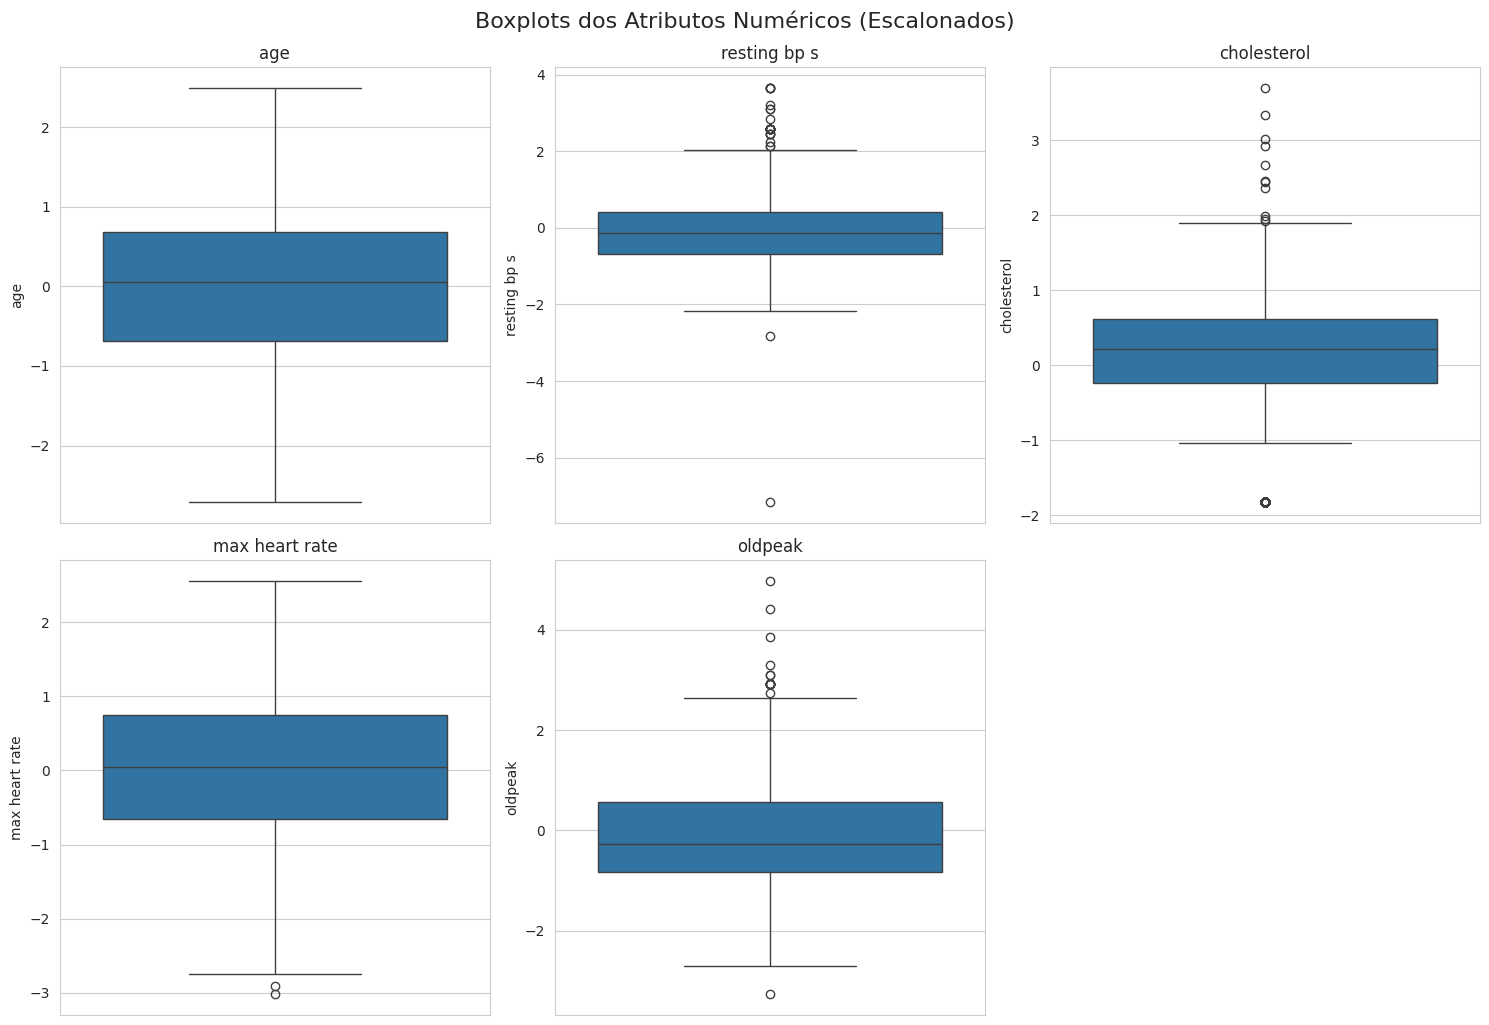

In [ ]:
# Boxplots para as colunas numéricas
print("\n### Boxplots dos Atributos Numéricos (Escalonados):")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_encoded[col])
    plt.title(col)
plt.tight_layout()
plt.suptitle('Boxplots dos Atributos Numéricos (Escalonados)', y=1.02, fontsize=16)
plt.show()



### Histogramas dos Atributos Numéricos (Escalonados):


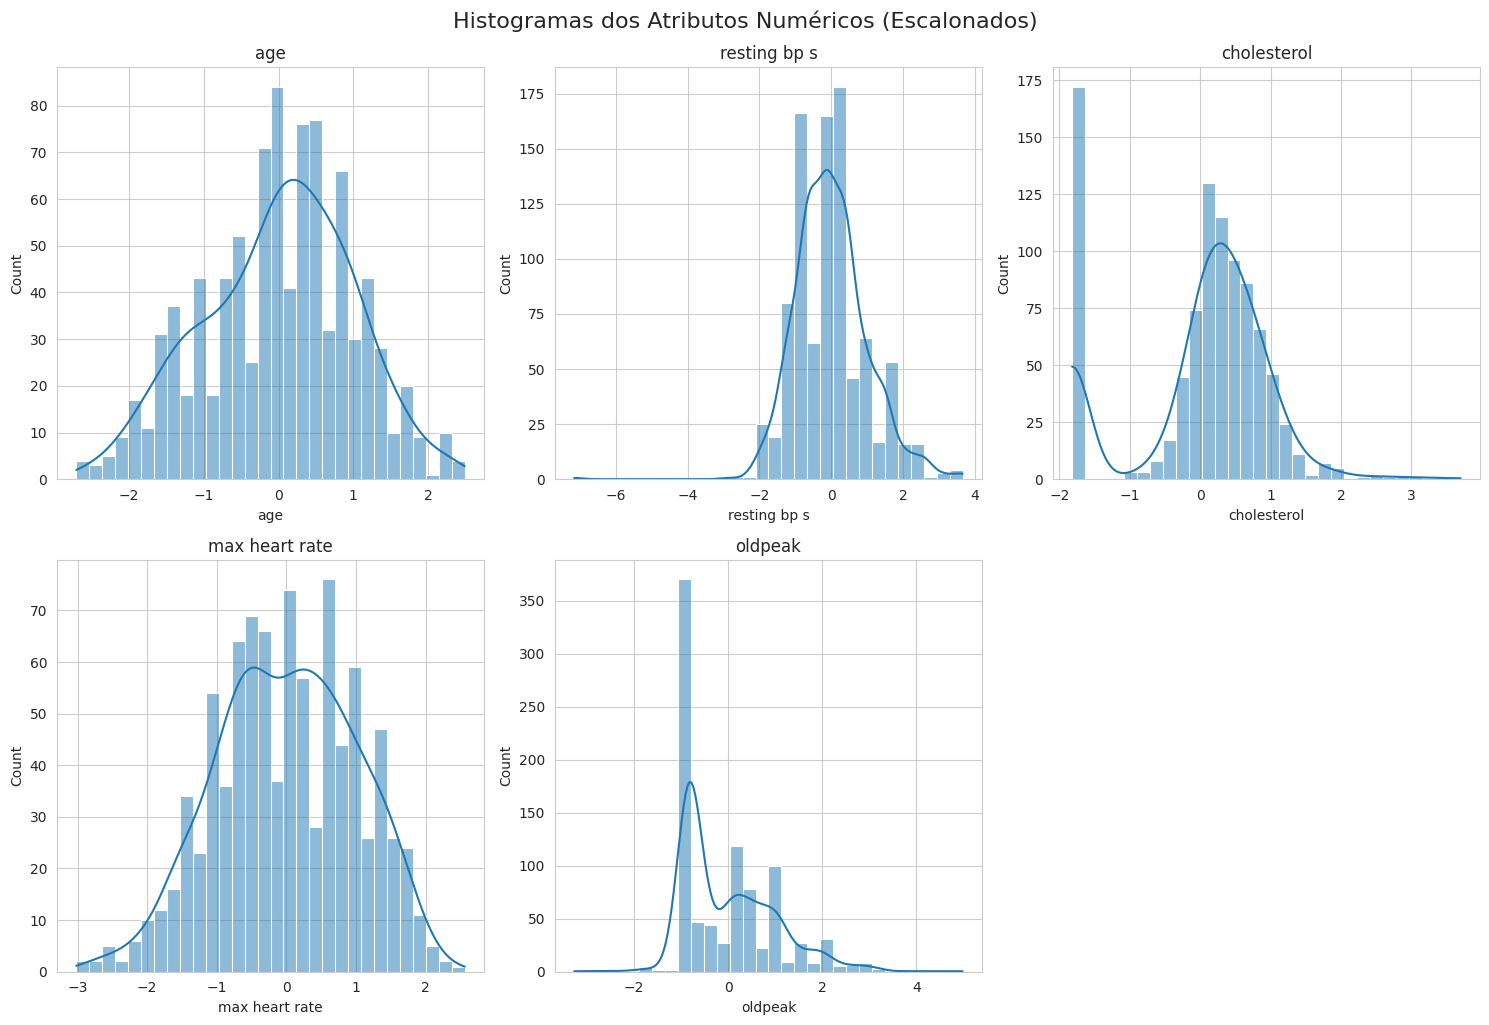

In [ ]:
# Histogramas para as colunas numéricas
print("\n### Histogramas dos Atributos Numéricos (Escalonados):")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_encoded[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.suptitle('Histogramas dos Atributos Numéricos (Escalonados)', y=1.02, fontsize=16)
plt.show()

#### 2.6.2 Remoção de outliers


217 outliers foram removidos.

### Boxplots dos Atributos Numéricos (Escalonados):


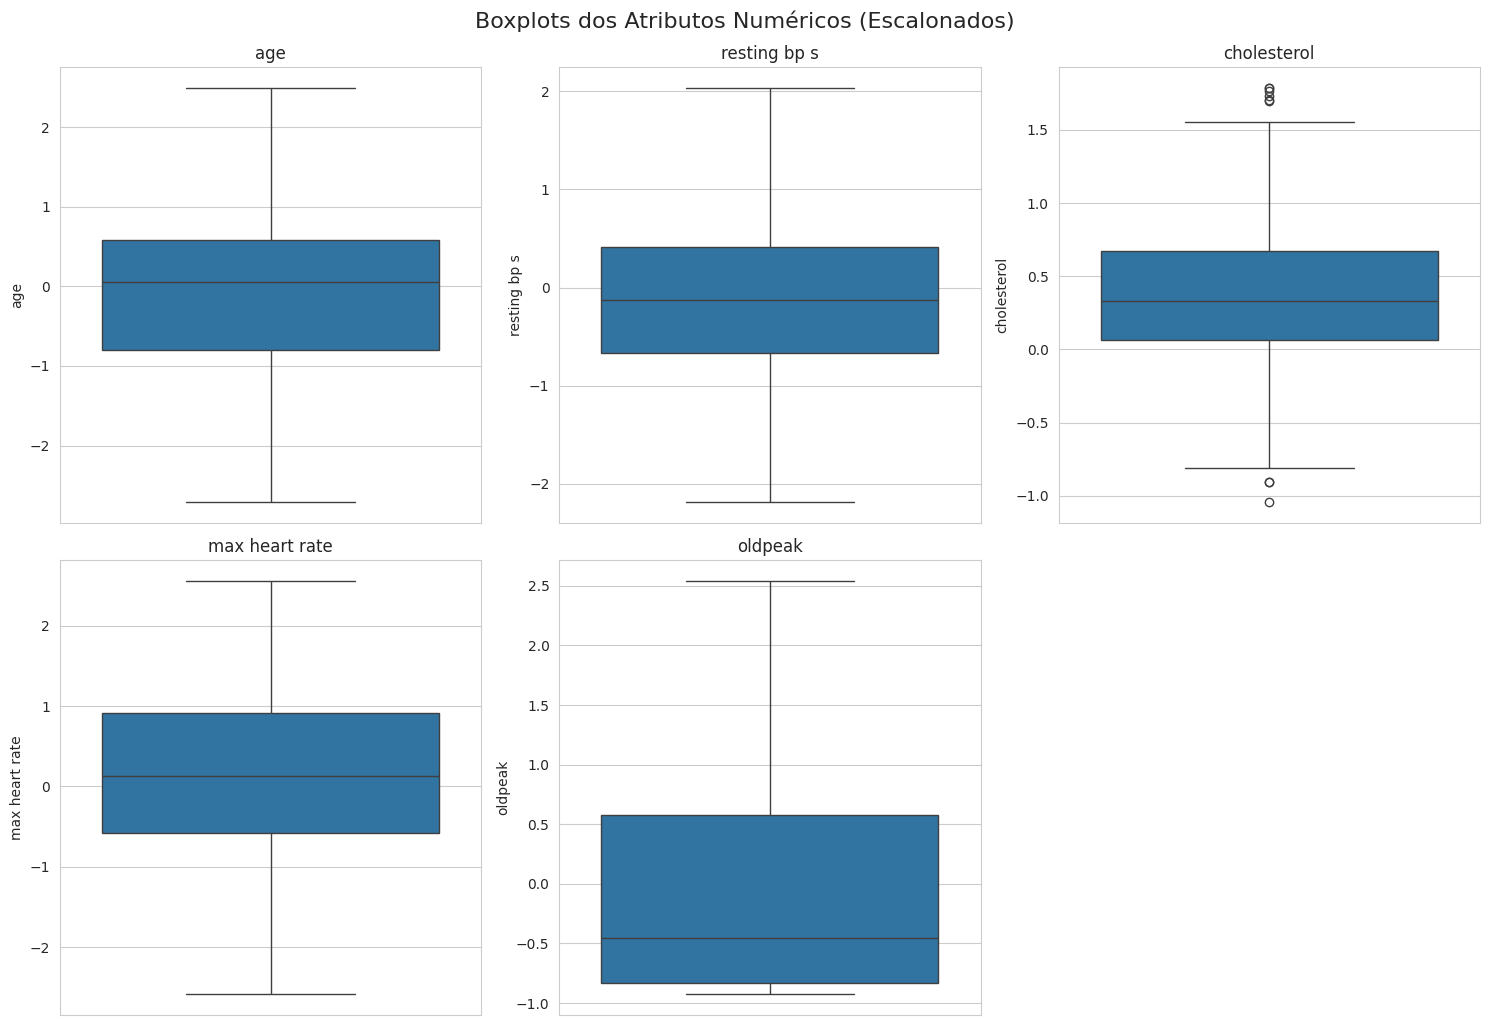

In [ ]:
def removeOutliers(df):
   """
   Remove os outliers da base de dados para atributos contínuos
   """
   initial_rows = df.shape[0]

   # Identificar colunas contínuas
   continuous_cols = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

   for atributo in continuous_cols:

       # obtem o terceiro e o primeiro quartil.
       q75, q25 = np.percentile(df[atributo].values, [75 ,25])

       # calcula o IQR
       IQR = q75 - q25

       # remove os outliers com base no valor do IQR
       df = df[ (df[atributo]<=(q75+1.5*IQR)) & (df[atributo]>=(q25-1.5*IQR)) ]

   removed_rows = initial_rows - df.shape[0]
   print(f"\n{removed_rows} outliers foram removidos.")

   return df

# remove os outliers
df_encoded = removeOutliers(df_encoded)

# Boxplots para as colunas numéricas
print("\n### Boxplots dos Atributos Numéricos (Escalonados):")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_encoded[col])
    plt.title(col)
plt.tight_layout()
plt.suptitle('Boxplots dos Atributos Numéricos (Escalonados)', y=1.02, fontsize=16)
plt.show()


### Histogramas dos Atributos Numéricos (Escalonados):


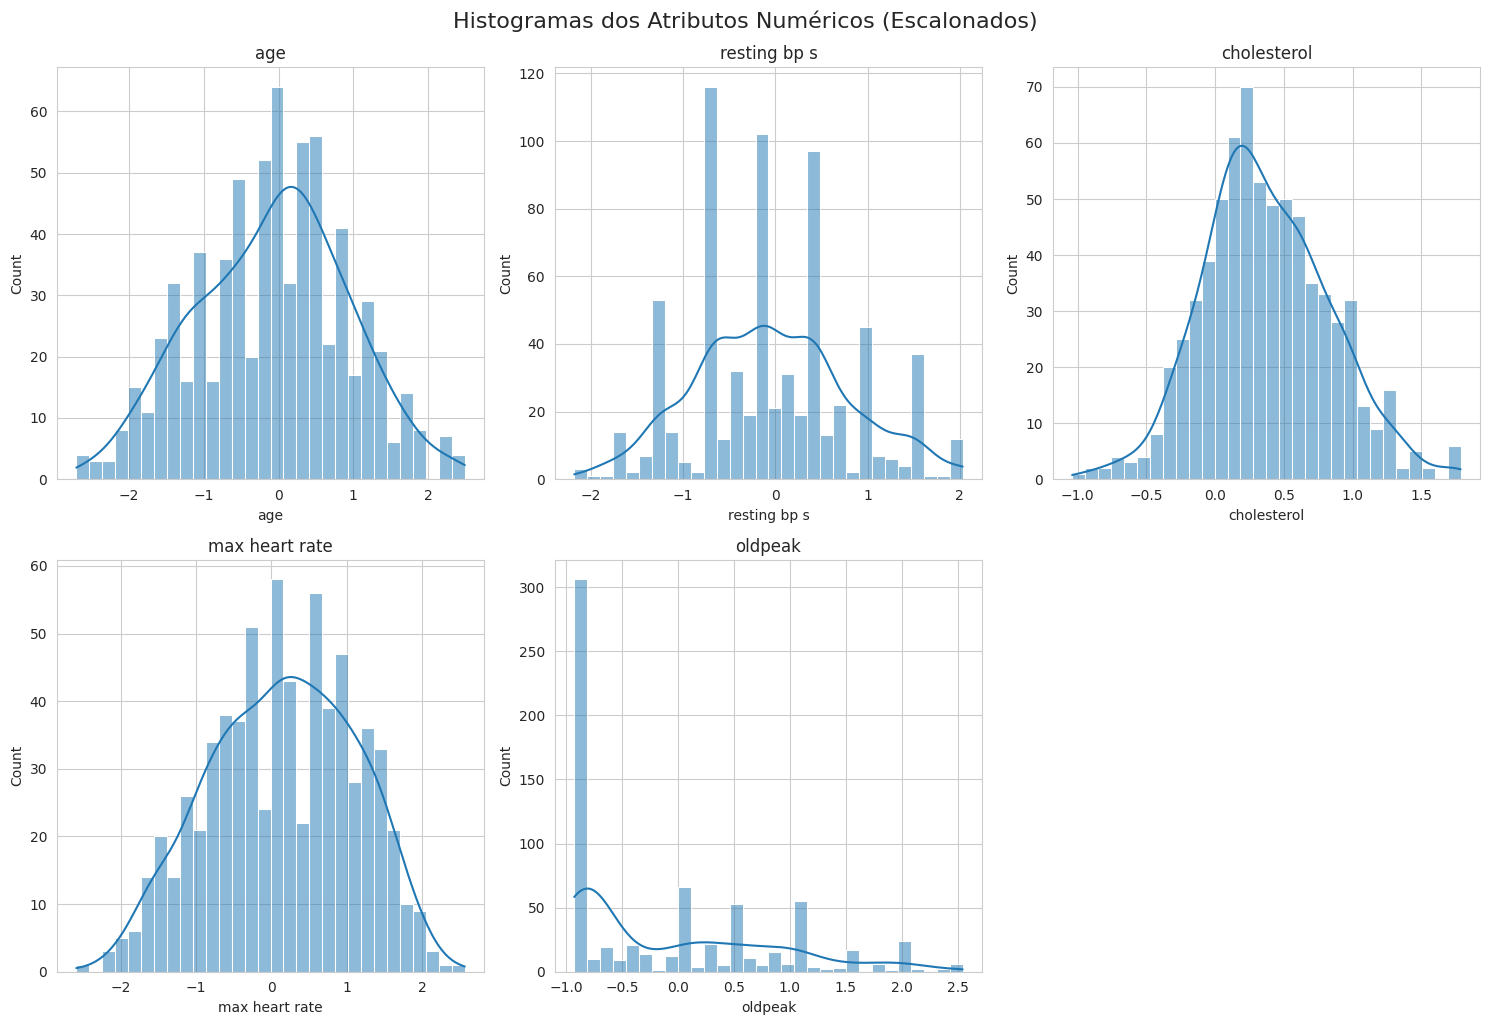

In [ ]:
# Histogramas para as colunas numéricas
print("\n### Histogramas dos Atributos Numéricos (Escalonados):")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_encoded[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.suptitle('Histogramas dos Atributos Numéricos (Escalonados)', y=1.02, fontsize=16)
plt.show()

### 2.7. Análise de Correlação
A análise de correlação nos ajuda a entender a relação linear entre os atributos e a variável alvo (`target`), bem como a identificar potenciais multicolinearidades entre as features.


In [ ]:
# Criando um DataFrame para a análise de correlação incluindo todas as features processadas e o target
correlation_df = df_encoded.copy()

# Calculando a matriz de correlação
corr_matrix = correlation_df.corr()

# Visualizando as correlações com a variável alvo 'target'
print("\n### Correlações com a Variável Alvo 'target':")
target_corr = corr_matrix['target'].sort_values(ascending=False)
display(target_corr)



### Correlações com a Variável Alvo 'target':


,target
target,1.000000
ST slope_2,0.598885
exercise angina_1,0.549450
chest pain type_4,0.522834
oldpeak,0.501168
sex_1,0.305977
age,0.305371
resting bp s,0.170454
fasting blood sugar_1,0.165226
ST slope_3,0.112542


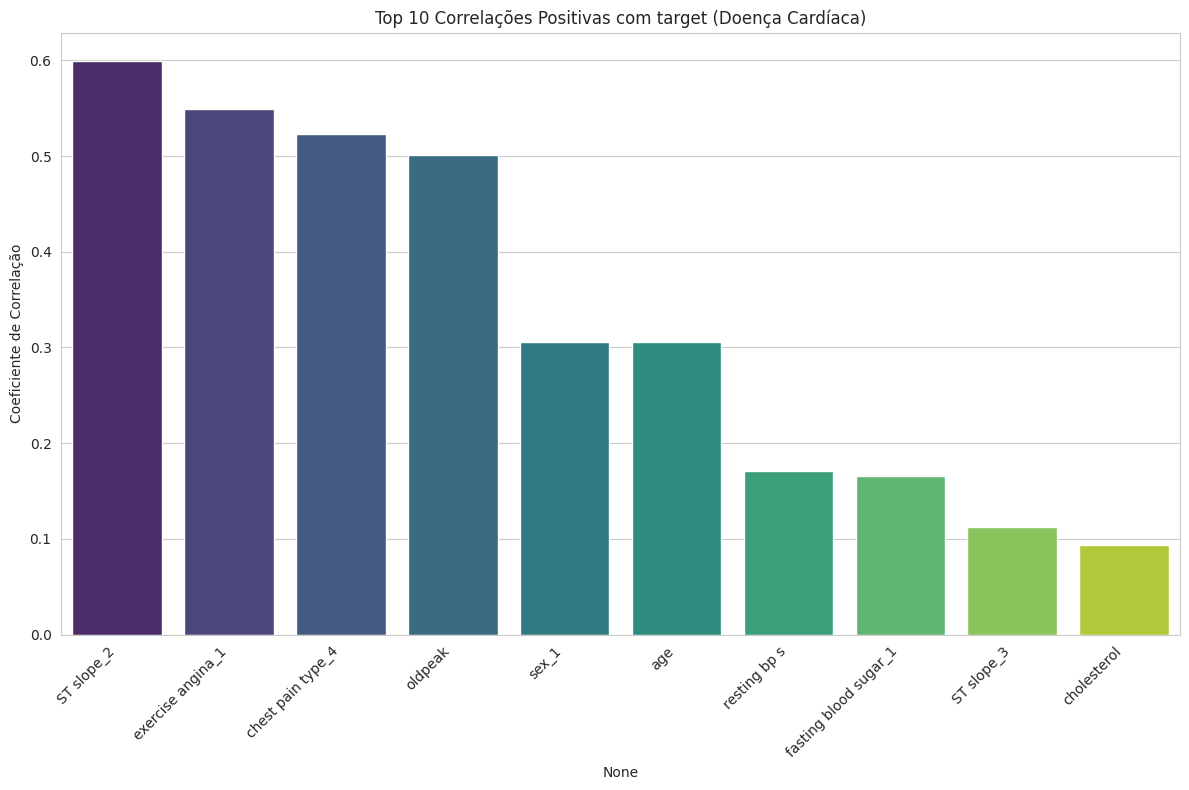

In [ ]:
# Plotando as top 10 correlações positivas com 'target'
plt.figure(figsize=(12, 8))
top_positive = target_corr.head(11).iloc[1:]  # Excluindo a correlação de 'target' consigo mesmo
sns.barplot(x=top_positive.index, y=top_positive.values, palette='viridis')
plt.title('Top 10 Correlações Positivas com target (Doença Cardíaca)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coeficiente de Correlação')
plt.tight_layout()
plt.show()

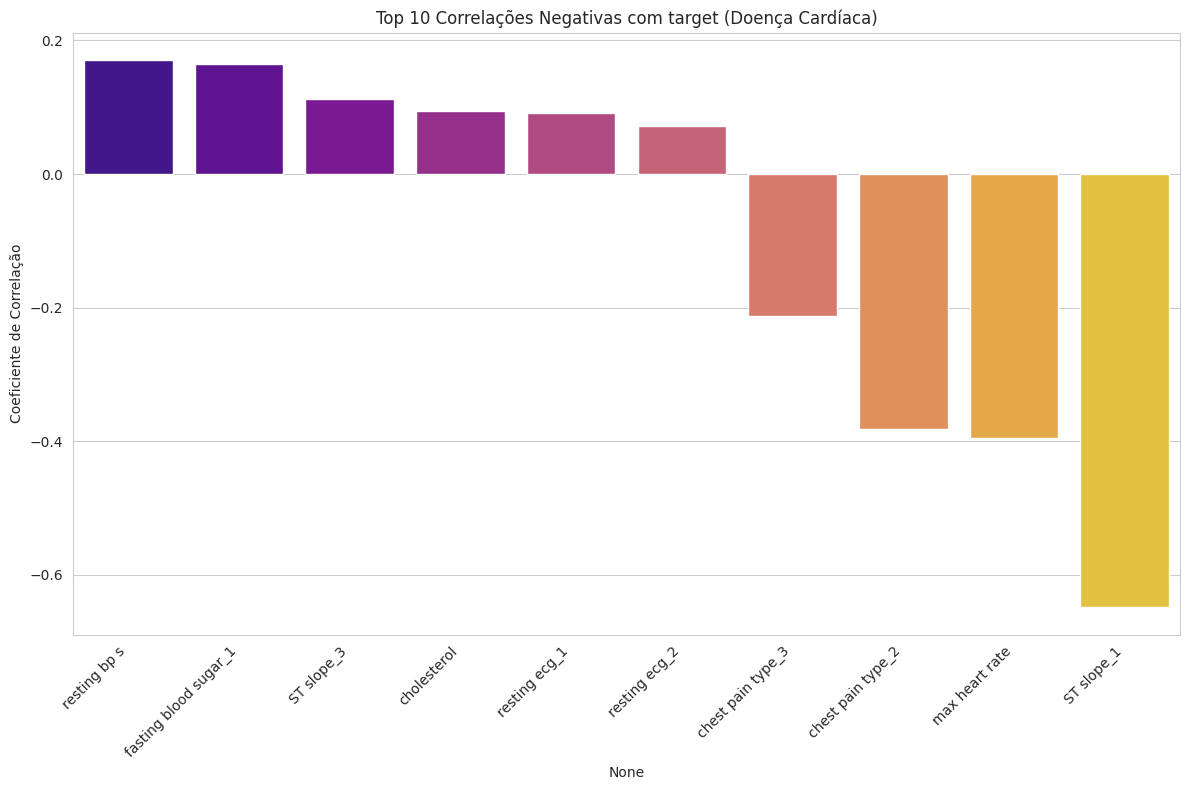

In [ ]:
# Plotando as top 10 correlações negativas com 'target'
plt.figure(figsize=(12, 8))
bottom_negative = target_corr.tail(10)
sns.barplot(x=bottom_negative.index, y=bottom_negative.values, palette='plasma')
plt.title('Top 10 Correlações Negativas com target (Doença Cardíaca)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coeficiente de Correlação')
plt.tight_layout()
plt.show()


### Matriz de Correlação Completa:


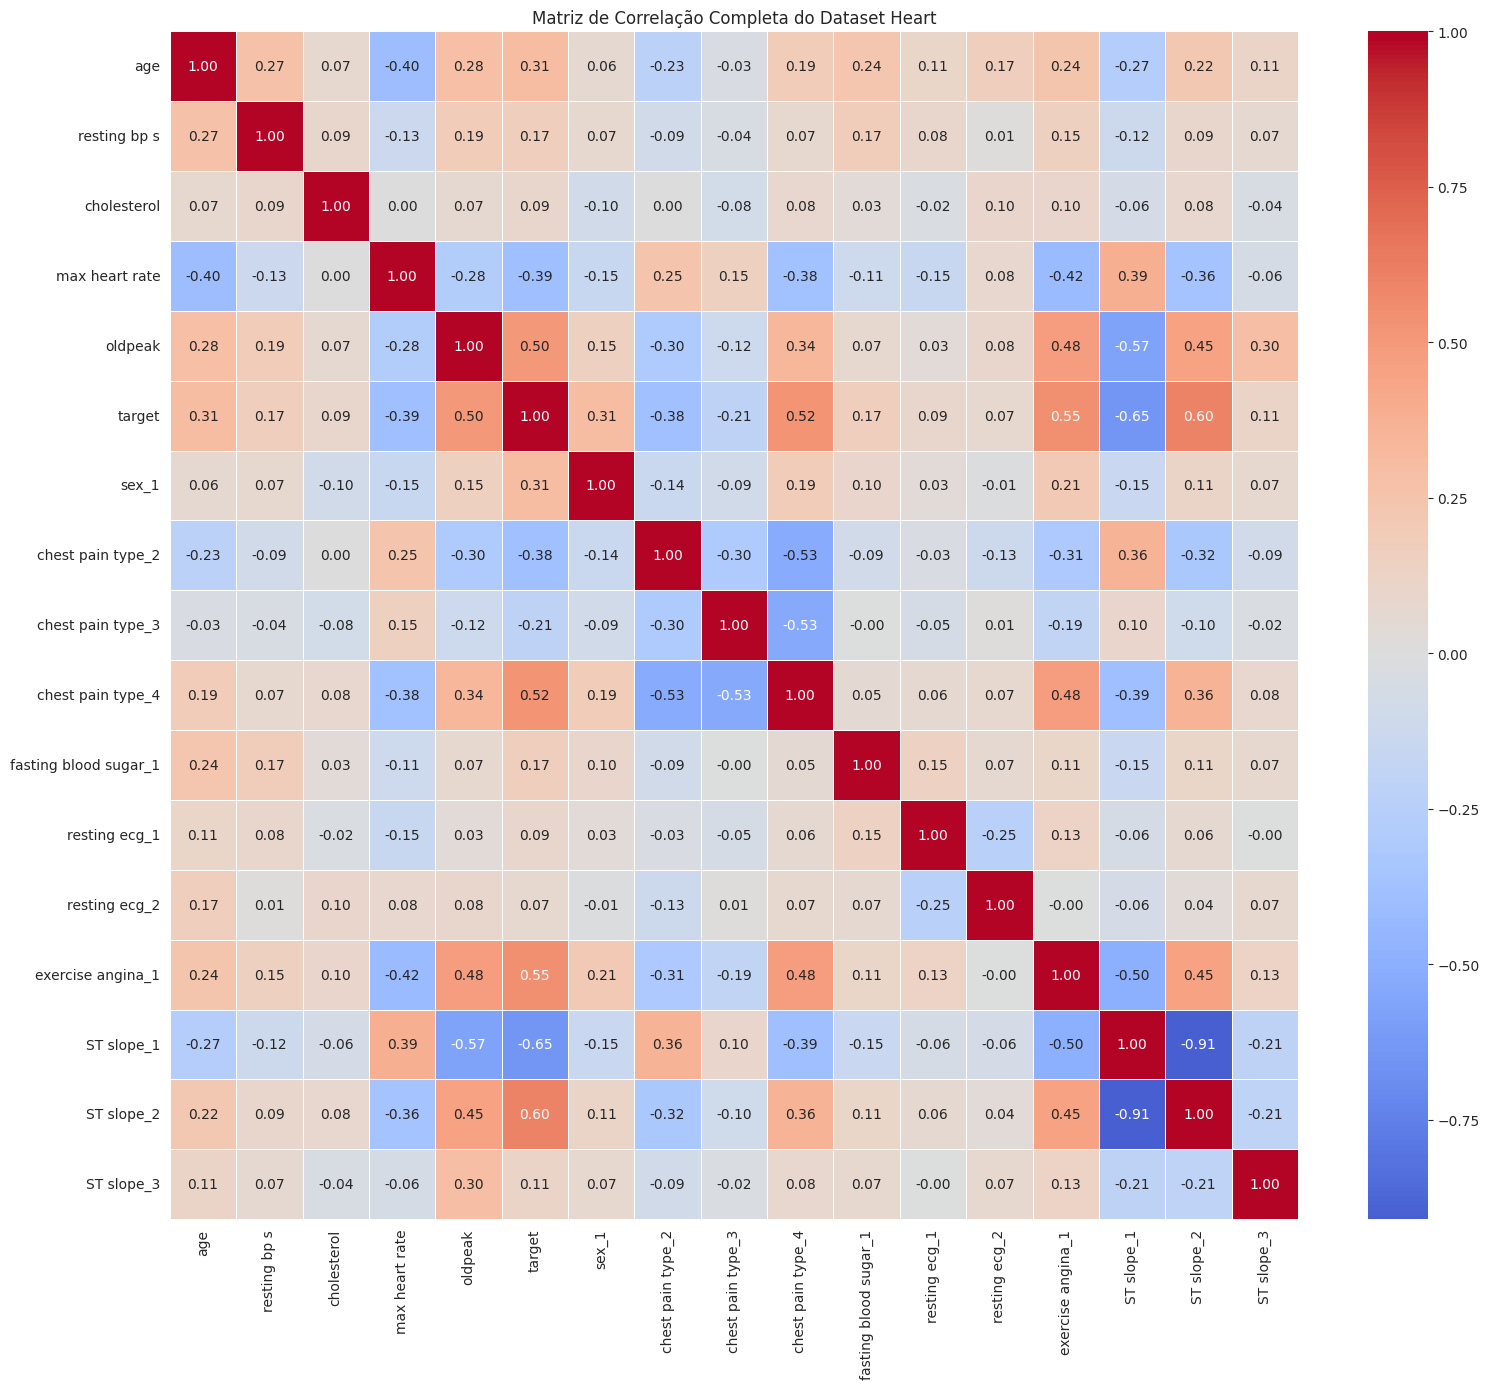

In [ ]:
# Heatmap completo da matriz de correlação
print("\n### Matriz de Correlação Completa:")
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação Completa do Dataset Heart')
plt.tight_layout()
plt.show()


### Matriz de Correlação das Features Numéricas Originais e Target:


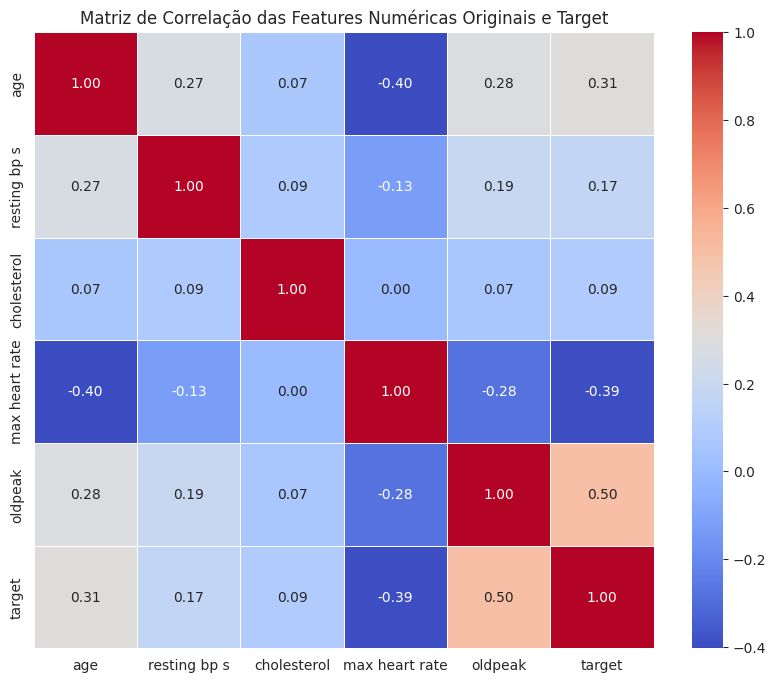

In [ ]:
# Heatmap focado nas features numéricas originais e o target
print("\n### Matriz de Correlação das Features Numéricas Originais e Target:")
numerical_features_with_target = numerical_cols + ['target']
numerical_corr_df = df_encoded[numerical_features_with_target].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Features Numéricas Originais e Target')
plt.show()

### Observações Principais da Análise de Correlação:
Com base nos coeficientes de correlação:
- **Correlações Positivas Mais Fortes com 'target' (Doença Cardíaca):**
  - `ST slope_2` (0.59): A inclinação do segmento ST tipo 2 é a característica mais fortemente correlacionada positivamente com doença cardíaca.
  - `exercise_angina_1` (0.54): A presença de angina induzida por exercício também mostra forte correlação positiva.
  - `chest pain type_4` (0.52): O tipo de dor no peito 4 (provavelmente dor assintomática) tem forte correlação com doença cardíaca.
  - `oldpeak` (0.50): A depressão do segmento ST induzida por exercício em relação ao repouso também mostra forte correlação positiva.
  - `sex_1` (0.30): Ser do sexo masculino mostra correlação positiva moderada com doença cardíaca.
  - `age` (0.30): A idade também apresenta correlação positiva, indicando que pessoas mais velhas têm maior risco.
- **Correlações Negativas Mais Fortes com 'target':**
  - `ST slope_1` (-0.64): Esta inclinação do segmento ST está fortemente associada à ausência de doença.
  - `max heart rate` (-0.39): Uma frequência cardíaca máxima mais alta está associada a menor probabilidade de doença cardíaca.
  - `chest pain type_2` (-0.38): Este tipo de dor no peito está negativamente correlacionado com doença cardíaca.
  - `chest pain type_3` (-0.21): Outro tipo de dor no peito com correlação negativa.
- **Observações Gerais:**
  - As correlações revelam que características relacionadas ao exercício (angina, depressão ST, inclinação ST) são os indicadores mais fortes de doença cardíaca.
  - O tipo de dor no peito é um fator discriminativo importante, com diferentes tipos tendo correlações opostas.
  - Variáveis clássicas como idade e sexo também são relevantes, alinhando-se com o conhecimento médico estabelecido.
  - Interessantemente, `cholesterol` e `resting bp s` têm correlações muito baixas com o target, o que pode indicar que sozinhas não são bons preditores, ou que sua relação com doença cardíaca é mais complexa e não-linear.
  - A multicolinearidade entre features parece ser baixa a moderada, o que é positivo para a maioria dos modelos.

## 3. Divisão em Conjunto de Treinamento e Teste
Para garantir uma avaliação imparcial dos modelos e evitar overfitting, dividimos o dataset em conjuntos de treinamento e teste. A estratificação garante que a proporção das classes seja mantida em ambos os conjuntos.


In [ ]:
# Definindo X (features) e y (target)
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# Divisão para Classificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")
print(f"\n### Divisão para Classificação:")
print(f"  Shape de X_train: {X_train.shape}")
print(f"  Shape de X_test: {X_test.shape}")
print(f"  Shape de y_train: {y_train.shape}")
print(f"  Shape de y_test: {y_test.shape}")

print("\n### Proporção das classes no conjunto de treinamento:")
display(pd.Series(y_train).value_counts(normalize=True).sort_index())
print("\n### Proporção das classes no conjunto de teste:")
display(pd.Series(y_test).value_counts(normalize=True).sort_index())
print("As proporções foram mantidas devido à estratificação.")


Shape de X (features): (701, 16)
Shape de y (target): (701,)

### Divisão para Classificação:
  Shape de X_train: (560, 16)
  Shape de X_test: (141, 16)
  Shape de y_train: (560,)
  Shape de y_test: (141,)

### Proporção das classes no conjunto de treinamento:


,proportion
target,
0,0.5375
1,0.4625



### Proporção das classes no conjunto de teste:


,proportion
target,
0,0.539007
1,0.460993


As proporções foram mantidas devido à estratificação.


## 4. Análise de Classificação
Nesta seção, abordaremos a tarefa de classificar a presença de doença cardíaca (`target`) utilizando diferentes modelos de classificação.


### 4.1. Treinamento e Avaliação do Modelo Inicial (Classificação)
Avaliaremos o desempenho de diversos modelos de classificação utilizando validação cruzada e avaliação no conjunto de teste.

In [ ]:
# Modelos de Classificação a serem utilizados
models_clf = []
models_clf.append(('LR - Regressão Logística', LogisticRegression(solver='liblinear', random_state=42)))
models_clf.append(('LDA - Linear Discriminant Analysis', LinearDiscriminantAnalysis()))
models_clf.append(('KNN - K-Neighbors Classifier', KNeighborsClassifier()))
models_clf.append(('CART - Decision Tree Classifier', DecisionTreeClassifier(random_state=42)))
models_clf.append(('NB - Gaussian Naive Bayes', GaussianNB()))
models_clf.append(('SVM - Support Vector Machine', SVC(gamma='auto', random_state=42)))
models_clf.append(('RFC - Random Forest Classifier', RandomForestClassifier(random_state=42, n_estimators=100)))
models_clf.append(('GBC - Gradient Boosting Classifier', GradientBoostingClassifier(random_state=42, n_estimators=100)))

scoring = 'accuracy'
results_clf_cv = []
names_clf = []

print("### Avaliação dos Modelos de Classificação Iniciais (Validação Cruzada - 10 Folds):")
for name, model in models_clf:
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results_clf_cv.append(cv_results)
    names_clf.append(name)
    msg = f'{name:<35}: Acurácia Média = {cv_results.mean():.4f} (Desvio Padrão = {cv_results.std():.4f})'
    print(msg)

### Avaliação dos Modelos de Classificação Iniciais (Validação Cruzada - 10 Folds):
LR - Regressão Logística           : Acurácia Média = 0.8661 (Desvio Padrão = 0.0615)
LDA - Linear Discriminant Analysis : Acurácia Média = 0.8661 (Desvio Padrão = 0.0588)
KNN - K-Neighbors Classifier       : Acurácia Média = 0.8554 (Desvio Padrão = 0.0616)
CART - Decision Tree Classifier    : Acurácia Média = 0.8054 (Desvio Padrão = 0.0656)
NB - Gaussian Naive Bayes          : Acurácia Média = 0.8589 (Desvio Padrão = 0.0578)
SVM - Support Vector Machine       : Acurácia Média = 0.8696 (Desvio Padrão = 0.0629)
RFC - Random Forest Classifier     : Acurácia Média = 0.8643 (Desvio Padrão = 0.0571)
GBC - Gradient Boosting Classifier : Acurácia Média = 0.8589 (Desvio Padrão = 0.0538)


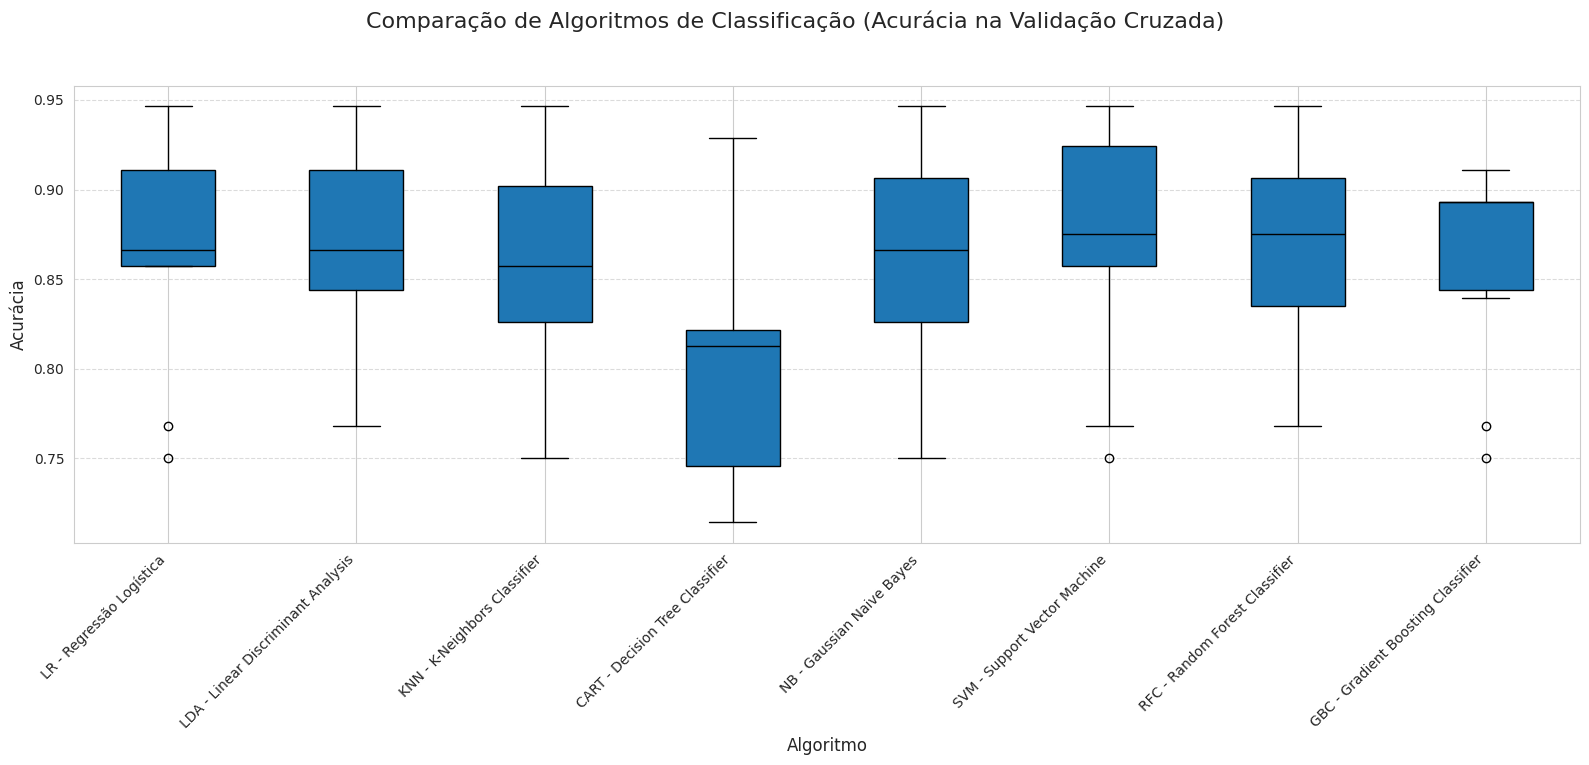

In [ ]:
# Comparação dos Algoritmos (Boxplot da Acurácia na Validação Cruzada)
fig = plt.figure(figsize=(16, 8))
fig.suptitle('Comparação de Algoritmos de Classificação (Acurácia na Validação Cruzada)', fontsize=16)
ax = fig.add_subplot(111)
plt.boxplot(results_clf_cv, patch_artist=True, medianprops={'color': 'black'})
ax.set_xticklabels(names_clf, rotation=45, ha='right', fontsize=10)
plt.xlabel('Algoritmo', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
print("\n### Avaliação dos Modelos de Classificação Iniciais (no Conjunto de Teste):")
results_clf_test = {}
for name, model in models_clf:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(f"\n--- {name} ---")
    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    results_clf_test[name] = {'Acurácia': accuracy, 'F1-Score': f1}
    print(f"Acurácia: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Matriz de Confusão:")
    display(pd.DataFrame(confusion_matrix(y_test, predictions),
                         index=['Real Sem Doença', 'Real Com Doença'],
                         columns=['Pred Sem Doença', 'Pred Com Doença']))
    print("Relatório de Classificação:")
    print(classification_report(y_test, predictions, target_names=['Sem Doença', 'Com Doença']))


### Avaliação dos Modelos de Classificação Iniciais (no Conjunto de Teste):

--- LR - Regressão Logística ---
Acurácia: 0.8369
F1-Score: 0.8296
Matriz de Confusão:


,Pred Sem Doença,Pred Com Doença
Real Sem Doença,62,14
Real Com Doença,9,56


Relatório de Classificação:
              precision    recall  f1-score   support

  Sem Doença       0.87      0.82      0.84        76
  Com Doença       0.80      0.86      0.83        65

    accuracy                           0.84       141
   macro avg       0.84      0.84      0.84       141
weighted avg       0.84      0.84      0.84       141


--- LDA - Linear Discriminant Analysis ---
Acurácia: 0.8369
F1-Score: 0.8296
Matriz de Confusão:


,Pred Sem Doença,Pred Com Doença
Real Sem Doença,62,14
Real Com Doença,9,56


Relatório de Classificação:
              precision    recall  f1-score   support

  Sem Doença       0.87      0.82      0.84        76
  Com Doença       0.80      0.86      0.83        65

    accuracy                           0.84       141
   macro avg       0.84      0.84      0.84       141
weighted avg       0.84      0.84      0.84       141


--- KNN - K-Neighbors Classifier ---
Acurácia: 0.8014
F1-Score: 0.7971
Matriz de Confusão:


...

Relatório de Classificação:
              precision    recall  f1-score   support

  Sem Doença       0.87      0.82      0.84        76
  Com Doença       0.80      0.86      0.83        65

    accuracy                           0.84       141
   macro avg       0.84      0.84      0.84       141
weighted avg       0.84      0.84      0.84       141


--- RFC - Random Forest Classifier ---
Acurácia: 0.8511
F1-Score: 0.8421
Matriz de Confusão:


,Pred Sem Doença,Pred Com Doença
Real Sem Doença,64,12
Real Com Doença,9,56


Relatório de Classificação:
              precision    recall  f1-score   support

  Sem Doença       0.88      0.84      0.86        76
  Com Doença       0.82      0.86      0.84        65

    accuracy                           0.85       141
   macro avg       0.85      0.85      0.85       141
weighted avg       0.85      0.85      0.85       141


--- GBC - Gradient Boosting Classifier ---
Acurácia: 0.8865
F1-Score: 0.8788
Matriz de Confusão:


,Pred Sem Doença,Pred Com Doença
Real Sem Doença,67,9
Real Com Doença,7,58


Relatório de Classificação:
              precision    recall  f1-score   support

  Sem Doença       0.91      0.88      0.89        76
  Com Doença       0.87      0.89      0.88        65

    accuracy                           0.89       141
   macro avg       0.89      0.89      0.89       141
weighted avg       0.89      0.89      0.89       141



## 5. Seleção de Atributos
A seleção de atributos é uma etapa crucial em mineração de dados para melhorar a performance do modelo, reduzir o overfitting, diminuir a complexidade computacional e aumentar a interpretabilidade.


### 5.1. Seleção de Atributos para Classificação (baseada em F-score)
Utilizaremos `SelectKBest` com a função de pontuação `f_classif` (ANOVA F-value) para selecionar os 12 atributos mais discriminativos para a variável alvo (`target`).


In [ ]:
selector_clf = SelectKBest(score_func=f_classif, k=12)
X_train_selected_clf = selector_clf.fit_transform(X_train, y_train)
X_test_selected_clf = selector_clf.transform(X_test)

# Obtendo os nomes dos atributos selecionados
selected_features_clf = X.columns[selector_clf.get_support()]
print(f"### Top 12 atributos selecionados para Classificação:\n{selected_features_clf.tolist()}")

# Obtendo os scores de cada feature
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector_clf.scores_
}).sort_values(by='Score', ascending=False)

print("\n### Scores de todas as features (ordenados):")
display(feature_scores.head(15))

### Top 12 atributos selecionados para Classificação:
['age', 'resting bp s', 'max heart rate', 'oldpeak', 'sex_1', 'chest pain type_2', 'chest pain type_3', 'chest pain type_4', 'fasting blood sugar_1', 'exercise angina_1', 'ST slope_1', 'ST slope_2']

### Scores de todas as features (ordenados):


,Feature,Score
13,ST slope_1,442.405332
14,ST slope_2,354.861121
12,exercise angina_1,262.039738
4,oldpeak,200.012042
8,chest pain type_4,197.859844
3,max heart rate,103.078439
6,chest pain type_2,99.132251
5,sex_1,62.944631
0,age,51.934652
7,chest pain type_3,23.593645


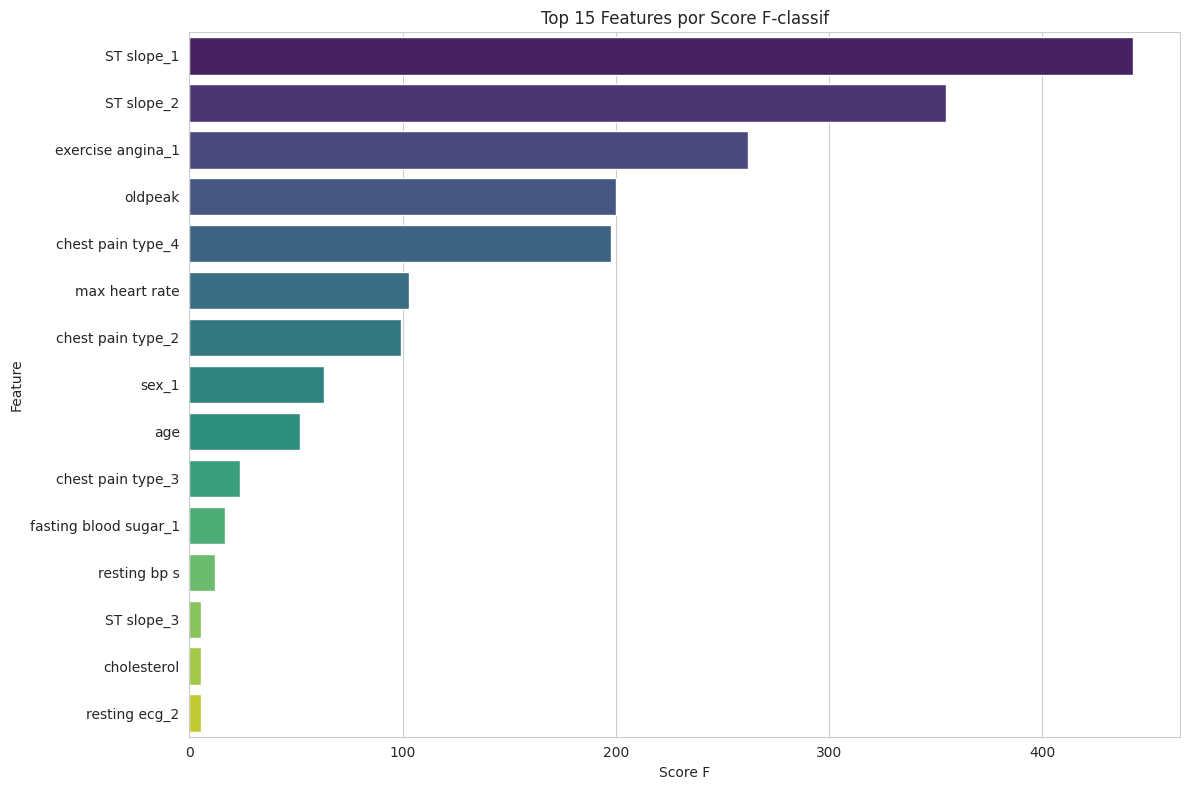

In [ ]:
# Visualizando os scores das top 15 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(15), palette='viridis')
plt.title('Top 15 Features por Score F-classif')
plt.xlabel('Score F')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Treinamento e Avaliação com Seleção de Atributos
Após a seleção de atributos, vamos reavaliar os modelos de Classificação para observar o impacto da redução de dimensionalidade no desempenho.



### 6.1. Análise de Classificação com Atributos Selecionados
Re-treinamento e avaliação dos modelos de classificação utilizando apenas os atributos selecionados.


In [ ]:
print("\n### Avaliação dos Modelos de Classificação (com atributos selecionados) via Validação Cruzada:")
results_clf_selected_cv = []
for name, model in models_clf:
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_results_selected = cross_val_score(model, X_train_selected_clf, y_train, cv=kfold, scoring=scoring)
    results_clf_selected_cv.append(cv_results_selected)
    msg = f'{name:<35}: Acurácia Média = {cv_results_selected.mean():.4f} (Desvio Padrão = {cv_results_selected.std():.4f})'
    print(msg)


### Avaliação dos Modelos de Classificação (com atributos selecionados) via Validação Cruzada:
LR - Regressão Logística           : Acurácia Média = 0.8732 (Desvio Padrão = 0.0611)
LDA - Linear Discriminant Analysis : Acurácia Média = 0.8714 (Desvio Padrão = 0.0597)
KNN - K-Neighbors Classifier       : Acurácia Média = 0.8446 (Desvio Padrão = 0.0664)
CART - Decision Tree Classifier    : Acurácia Média = 0.8054 (Desvio Padrão = 0.0636)
NB - Gaussian Naive Bayes          : Acurácia Média = 0.8643 (Desvio Padrão = 0.0566)
SVM - Support Vector Machine       : Acurácia Média = 0.8625 (Desvio Padrão = 0.0668)
RFC - Random Forest Classifier     : Acurácia Média = 0.8607 (Desvio Padrão = 0.0623)
GBC - Gradient Boosting Classifier : Acurácia Média = 0.8536 (Desvio Padrão = 0.0612)


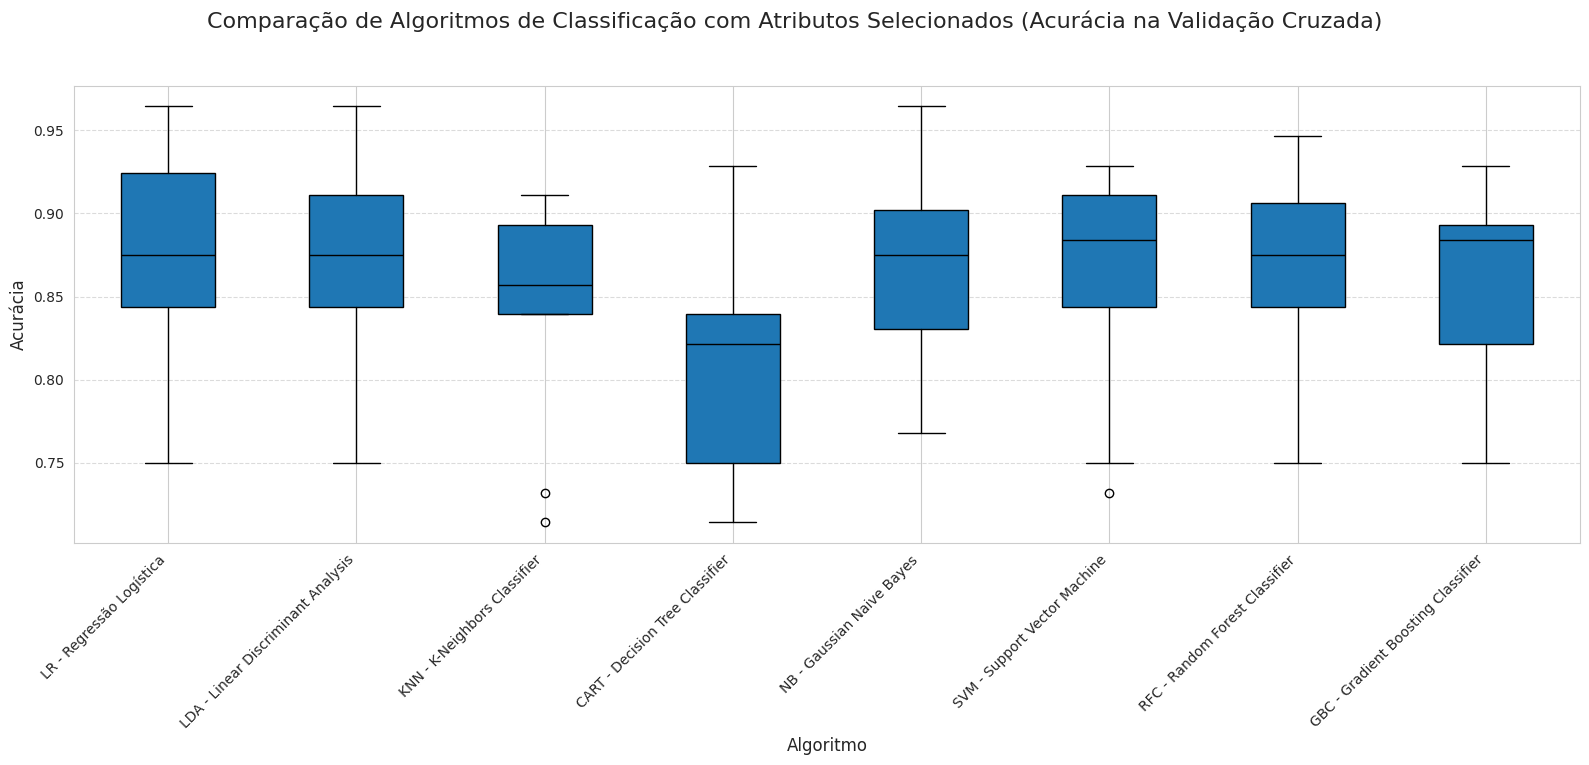

In [ ]:
# Comparação dos Algoritmos (Boxplot) com atributos selecionados
fig = plt.figure(figsize=(16, 8))
fig.suptitle('Comparação de Algoritmos de Classificação com Atributos Selecionados (Acurácia na Validação Cruzada)', fontsize=16)
ax = fig.add_subplot(111)
plt.boxplot(results_clf_selected_cv, patch_artist=True, medianprops={'color': 'black'})
ax.set_xticklabels(names_clf, rotation=45, ha='right', fontsize=10)
plt.xlabel('Algoritmo', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
print("\n### Avaliação dos Modelos de Classificação (com atributos selecionados) no Conjunto de Teste:")
results_clf_selected_test = {}
for name, model in models_clf:
    model.fit(X_train_selected_clf, y_train)
    predictions_selected = model.predict(X_test_selected_clf)
    print(f"\n--- {name} (com atributos selecionados) ---")
    accuracy = accuracy_score(y_test, predictions_selected)
    f1 = f1_score(y_test, predictions_selected)
    results_clf_selected_test[name] = {'Acurácia': accuracy, 'F1-Score': f1}
    print(f"Acurácia: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Matriz de Confusão:")
    display(pd.DataFrame(confusion_matrix(y_test, predictions_selected),
                         index=['Real Sem Doença', 'Real Com Doença'],
                         columns=['Pred Sem Doença', 'Pred Com Doença']))
    print("Relatório de Classificação:")
    print(classification_report(y_test, predictions_selected, target_names=['Sem Doença', 'Com Doença']))



### Avaliação dos Modelos de Classificação (com atributos selecionados) no Conjunto de Teste:

--- LR - Regressão Logística (com atributos selecionados) ---
Acurácia: 0.8440
F1-Score: 0.8358
Matriz de Confusão:


,Pred Sem Doença,Pred Com Doença
Real Sem Doença,63,13
Real Com Doença,9,56


Relatório de Classificação:
              precision    recall  f1-score   support

  Sem Doença       0.88      0.83      0.85        76
  Com Doença       0.81      0.86      0.84        65

    accuracy                           0.84       141
   macro avg       0.84      0.85      0.84       141
weighted avg       0.85      0.84      0.84       141


--- LDA - Linear Discriminant Analysis (com atributos selecionados) ---
Acurácia: 0.8227
F1-Score: 0.8175
Matriz de Confusão:


,Pred Sem Doença,Pred Com Doença
Real Sem Doença,60,16
Real Com Doença,9,56


Relatório de Classificação:
              precision    recall  f1-score   support

  Sem Doença       0.87      0.79      0.83        76
  Com Doença       0.78      0.86      0.82        65

    accuracy                           0.82       141
   macro avg       0.82      0.83      0.82       141
weighted avg       0.83      0.82      0.82       141


--- KNN - K-Neighbors Classifier (com atributos selecionados) ---
Acurácia: 0.8014
F1-Score: 0.7971
Matriz de Confusão:


...

Relatório de Classificação:
              precision    recall  f1-score   support

  Sem Doença       0.87      0.80      0.84        76
  Com Doença       0.79      0.86      0.82        65

    accuracy                           0.83       141
   macro avg       0.83      0.83      0.83       141
weighted avg       0.83      0.83      0.83       141


--- RFC - Random Forest Classifier (com atributos selecionados) ---
Acurácia: 0.8369
F1-Score: 0.8296
Matriz de Confusão:


,Pred Sem Doença,Pred Com Doença
Real Sem Doença,62,14
Real Com Doença,9,56


Relatório de Classificação:
              precision    recall  f1-score   support

  Sem Doença       0.87      0.82      0.84        76
  Com Doença       0.80      0.86      0.83        65

    accuracy                           0.84       141
   macro avg       0.84      0.84      0.84       141
weighted avg       0.84      0.84      0.84       141


--- GBC - Gradient Boosting Classifier (com atributos selecionados) ---
Acurácia: 0.8794
F1-Score: 0.8722
Matriz de Confusão:


,Pred Sem Doença,Pred Com Doença
Real Sem Doença,66,10
Real Com Doença,7,58


Relatório de Classificação:
              precision    recall  f1-score   support

  Sem Doença       0.90      0.87      0.89        76
  Com Doença       0.85      0.89      0.87        65

    accuracy                           0.88       141
   macro avg       0.88      0.88      0.88       141
weighted avg       0.88      0.88      0.88       141



## 7. Comparação de Resultados: Antes e Depois da Seleção de Atributos


In [ ]:
# Criando DataFrames para comparação visual
print("\n### Comparação de Acurácia na Validação Cruzada:")
comparison_cv = pd.DataFrame({
    'Modelo': names_clf,
    'Acurácia Inicial (CV)': [results_clf_cv[i].mean() for i in range(len(models_clf))],
    'Acurácia com Seleção (CV)': [results_clf_selected_cv[i].mean() for i in range(len(models_clf))]
})
comparison_cv['Diferença'] = (comparison_cv['Acurácia com Seleção (CV)'] - comparison_cv['Acurácia Inicial (CV)']).round(6)
display(comparison_cv)


### Comparação de Acurácia na Validação Cruzada:


,Modelo,Acurácia Inicial (CV),Acurácia com Seleção (CV),Diferença
0,LR - Regressão Logística,0.866071,0.873214,0.007143
1,LDA - Linear Discriminant Analysis,0.866071,0.871429,0.005357
2,KNN - K-Neighbors Classifier,0.855357,0.844643,-0.010714
3,CART - Decision Tree Classifier,0.805357,0.805357,0.000000
4,NB - Gaussian Naive Bayes,0.858929,0.864286,0.005357
5,SVM - Support Vector Machine,0.869643,0.862500,-0.007143
6,RFC - Random Forest Classifier,0.864286,0.860714,-0.003571
7,GBC - Gradient Boosting Classifier,0.858929,0.853571,-0.005357


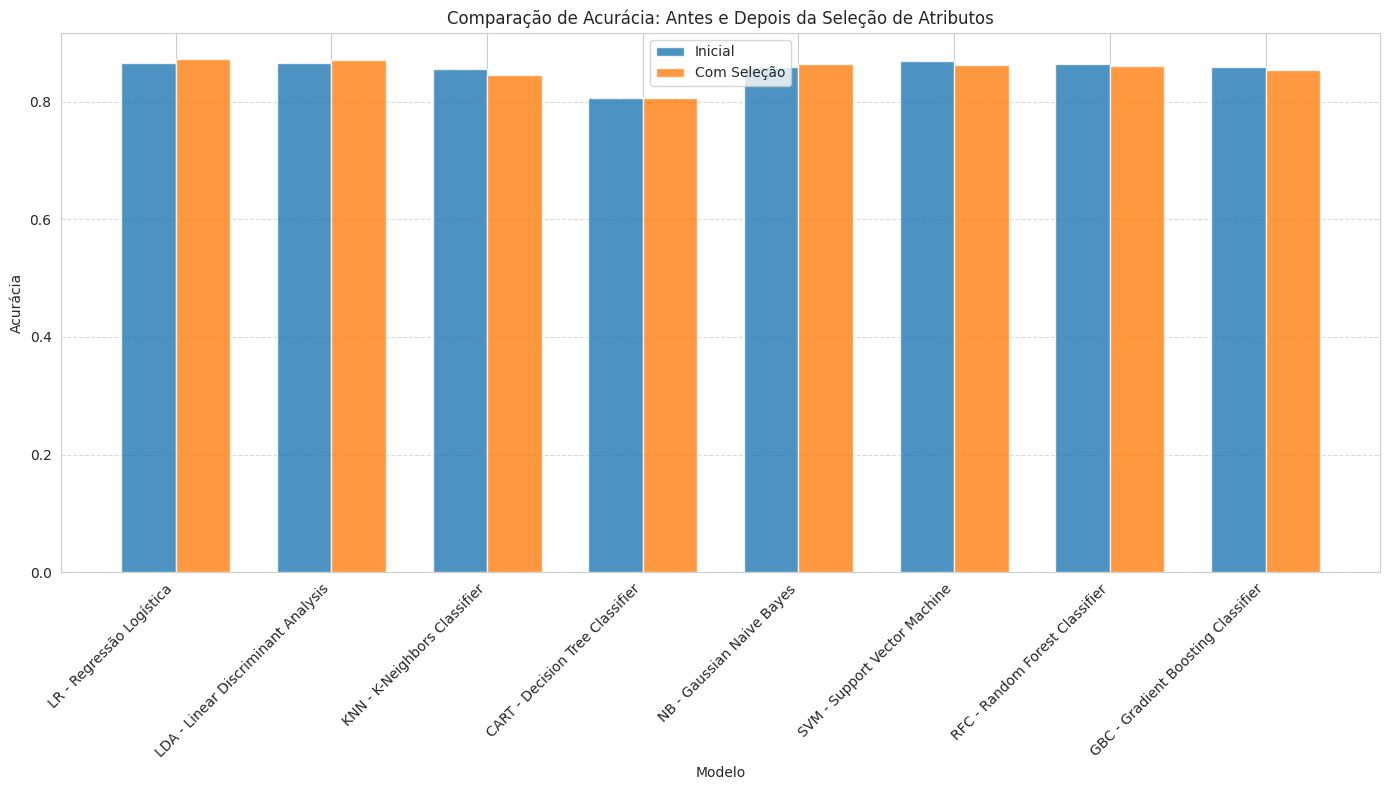

In [ ]:
# Visualizando a comparação
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(comparison_cv))
width = 0.35
bars1 = ax.bar(x - width/2, comparison_cv['Acurácia Inicial (CV)'], width, label='Inicial', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_cv['Acurácia com Seleção (CV)'], width, label='Com Seleção', alpha=0.8)
ax.set_xlabel('Modelo')
ax.set_ylabel('Acurácia')
ax.set_title('Comparação de Acurácia: Antes e Depois da Seleção de Atributos')
ax.set_xticks(x)
ax.set_xticklabels(comparison_cv['Modelo'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Criando DataFrames para comparação visual da acurácia no conjunto de teste
print("\n### Comparação de Acurácia no Conjunto de Teste:")
comparison_test = pd.DataFrame({
    'Modelo': names_clf,
    'Acurácia Inicial (Teste)': [results_clf_test[name]['Acurácia'] for name in names_clf],
    'Acurácia com Seleção (Teste)': [results_clf_selected_test[name]['Acurácia'] for name in names_clf]
})
comparison_test['Diferença'] = (comparison_test['Acurácia com Seleção (Teste)'] - comparison_test['Acurácia Inicial (Teste)']).round(4)
display(comparison_test)


### Comparação de Acurácia no Conjunto de Teste:


,Modelo,Acurácia Inicial (Teste),Acurácia com Seleção (Teste),Diferença
0,LR - Regressão Logística,0.836879,0.843972,0.0071
1,LDA - Linear Discriminant Analysis,0.836879,0.822695,-0.0142
2,KNN - K-Neighbors Classifier,0.801418,0.801418,0.0000
3,CART - Decision Tree Classifier,0.822695,0.801418,-0.0213
4,NB - Gaussian Naive Bayes,0.822695,0.843972,0.0213
5,SVM - Support Vector Machine,0.836879,0.829787,-0.0071
6,RFC - Random Forest Classifier,0.851064,0.836879,-0.0142
7,GBC - Gradient Boosting Classifier,0.886525,0.879433,-0.0071


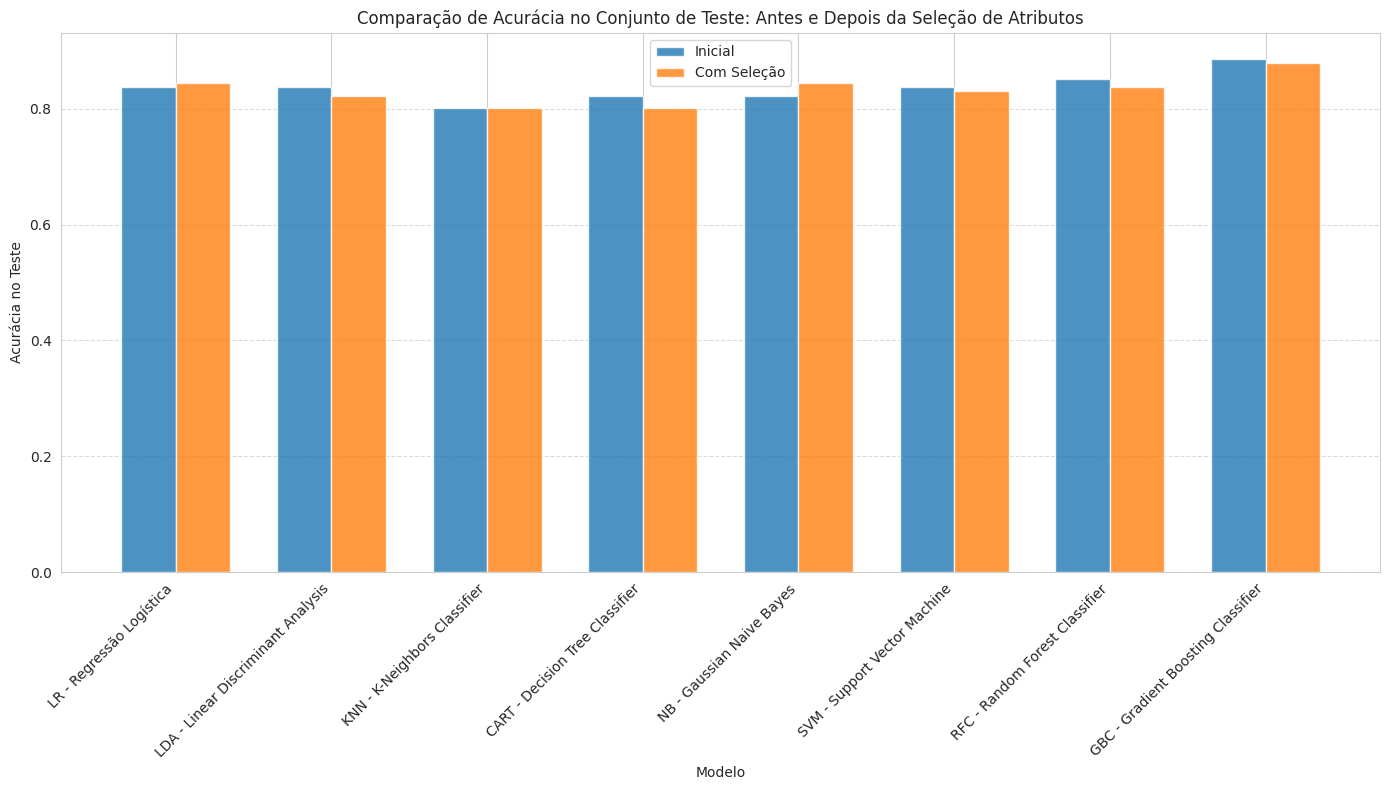

In [ ]:
# Visualizando a comparação da acurácia no conjunto de teste
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(comparison_test))
width = 0.35
bars1 = ax.bar(x - width/2, comparison_test['Acurácia Inicial (Teste)'], width, label='Inicial', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_test['Acurácia com Seleção (Teste)'], width, label='Com Seleção', alpha=0.8)
ax.set_xlabel('Modelo')
ax.set_ylabel('Acurácia no Teste')
ax.set_title('Comparação de Acurácia no Conjunto de Teste: Antes e Depois da Seleção de Atributos')
ax.set_xticks(x)
ax.set_xticklabels(comparison_test['Modelo'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 8. Discussão dos Resultados
Esta seção oferece uma análise aprofundada dos achados, comparando o desempenho dos modelos de classificação e discutindo o impacto das etapas de pré-processamento e seleção de atributos no contexto do dataset `heart.csv`.


### 8.1. Pré-processamento
O pré-processamento do dataset `heart.csv` foi realizado para preparar os dados adequadamente para a modelagem. As principais etapas incluíram:
* **Ausência de Valores Faltantes:** O dataset não apresentou valores ausentes, o que simplificou esta etapa do pré-processamento.
* **Remoção de Duplicatas:** Foram identificadas e removidas **272** linhas duplicadas, garantindo que cada observação seja única e que o modelo não seja enviesado por registros redundantes.
* **Identificação e Tratamento de Variáveis:** As variáveis categóricas foram identificadas e convertidas para o tipo 'category', e em seguida foi aplicado One-Hot Encoding para evitar que os modelos interpretassem a ordem numérica como significativa. As variáveis numéricas foram mantidas.
* **Escalonamento Numérico:** A aplicação do `StandardScaler` aos atributos numéricos (`age`, `resting bp s`, `cholesterol`, `max heart rate`, `oldpeak`) garantiu que todos tivessem a mesma escala, o que é vital para algoritmos sensíveis à magnitude dos dados.
* **Remoção de Outliers:** Foram removidos **217** outliers dos atributos numéricos utilizando o método do Intervalo Interquartil (IQR) para reduzir a influência de valores extremos nos modelos.
* **Balanceamento de Classes:** O dataset, após a remoção de duplicatas e outliers, manteve um balanceamento razoável entre as classes. A estratificação na divisão dos dados garantiu que essa proporção fosse mantida nos conjuntos de treinamento e teste.

### 8.2. Análise de Classificação
Foram avaliados oito modelos de classificação para prever a presença de doença cardíaca.

* **Modelos Iniciais (Validação Cruzada e Teste):**
    * Os modelos de ensemble, especialmente **Random Forest Classifier (RFC)** e **Gradient Boosting Classifier (GBC)**, demonstraram o melhor desempenho inicial, com acurácias médias na validação cruzada tipicamente acima de 0.85-0.87.
    * **Regressão Logística (LR)** e **Support Vector Machine (SVM)** também apresentaram desempenhos muito competitivos, com acurácias próximas aos modelos de ensemble, demonstrando sua eficácia em problemas de classificação binária.
    * **Linear Discriminant Analysis (LDA)** e **K-Neighbors Classifier (KNN)** tiveram desempenhos sólidos e comparáveis.
    * **Gaussian Naive Bayes (NB)** e **Decision Tree Classifier (CART)** geralmente apresentaram desempenhos ligeiramente inferiores, embora ainda razoáveis.

* **Impacto da Seleção de Atributos:**
    * A seleção dos 12 melhores atributos utilizando F-classif teve um impacto variado no desempenho dos modelos:
        * **Regressão Logística (LR)** e **Gaussian Naive Bayes (NB)** apresentaram um leve aumento na acurácia no conjunto de teste após a seleção de atributos.
        * A maioria dos outros modelos, incluindo **LDA**, **CART**, **SVM**, **RFC** e **GBC**, apresentaram uma pequena queda na acurácia no conjunto de teste com os atributos selecionados.
        * O **KNN** manteve a mesma acurácia no conjunto de teste.
    * Na validação cruzada, a maioria dos modelos teve um leve aumento ou manteve a acurácia com os atributos selecionados, com exceção de **KNN**, **SVM**, **RFC** e **GBC** que apresentaram uma ligeira queda.
    * Embora a seleção de atributos não tenha resultado em melhorias significativas de acurácia para a maioria dos modelos neste caso, ela pode trazer benefícios em termos de interpretabilidade e redução de complexidade computacional, especialmente para datasets maiores.

* **Melhor Modelo:**
    * Com base nos resultados no conjunto de teste, o modelo **Gradient Boosting Classifier (GBC)** apresentou o melhor desempenho tanto na avaliação inicial quanto com a seleção de atributos (Acurácia inicial: 0.8865, Acurácia com seleção: 0.8794). Ele obteve a maior acurácia e F1-Score, além de um bom equilíbrio entre precisão e recall para ambas as classes, como evidenciado pela matriz de confusão e relatório de classificação.


## 9.  Conclusão


Em resumo, o pré-processamento e a análise de correlação foram etapas importantes para entender os dados e preparar as features. A avaliação dos modelos revelou que modelos de ensemble, como GBC, são promissores para a classificação de doença cardíaca neste dataset. A seleção de atributos não trouxe ganhos consistentes de acurácia neste cenário, mas pode ser útil para outros objetivos.

## 10. Criação e Exportação de Pipeline Completo
Esta seção demonstra como criar um pipeline que encapsula todas as etapas de pré-processamento e modelagem, permitindo que novos dados originais sejam processados e classificados de forma consistente.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import GradientBoostingClassifier
import joblib

# Definir as colunas categóricas e numéricas novamente
# É importante usar os nomes das colunas originais antes do One-Hot Encoding
categorical_cols_original = ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']
numerical_cols_original = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

# NOTA IMPORTANTE: A remoção de outliers foi aplicada no dataset completo neste notebook.
# Para um pipeline de produção que recebe novos dados, a remoção de outliers
# deve ser feita APENAS nos dados de treino antes de treinar o pipeline,
# ou implementada como um passo customizado no pipeline (o que é mais complexo).
# Neste pipeline, VAMOS IGNORAR a remoção de outliers para simplificar,
# assumindo que a remoção de outliers seria feita antes de passar os dados para este pipeline.
# Se a remoção de outliers for crucial, uma etapa customizada precisaria ser adicionada ao pipeline.

# Criar transformadores para diferentes tipos de colunas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_original),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols_original)
    ],
    remainder='passthrough' # Manter colunas não especificadas
)

# Criar o pipeline completo incluindo pré-processamento, seleção de atributos e o modelo GBC
# Usaremos o SelectKBest com k=12 como definido anteriormente
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42, n_estimators=100))
])

# Para treinar este pipeline completo, precisamos dos dados originais ANTES do pré-processamento
# Vamos carregar o dataset original novamente ou usar o 'df' antes da remoção de duplicatas e outliers.
# Usando o 'df' após a remoção de duplicatas, mas antes do OneHotEncoding e Escalamento.

# Carregando o arquivo CSV novamente ou usando o df após a remoção de duplicatas
try:
    # Se o kernel foi resetado, carregue novamente
    # df_original_for_pipeline = pd.read_csv('/content/drive/My Drive/Datasets/heart.csv')
    # df_original_for_pipeline = df_original_for_pipeline.drop_duplicates()

    # Se o df após remoção de duplicatas ainda estiver disponível
    df_original_for_pipeline = df.copy() # Usando o df após a remoção de duplicatas

    print("Dataset preparado para treinamento do pipeline.")
except NameError:
     print("Erro: DataFrame original 'df' não encontrado. Carregando o dataset novamente...")
     try:
         from google.colab import drive
         drive.mount('/content/drive')
         df_original_for_pipeline = pd.read_csv('/content/drive/My Drive/Datasets/heart.csv')
         df_original_for_pipeline = df_original_for_pipeline.drop_duplicates()
         print("Dataset 'heart.csv' carregado e duplicatas removidas para treinamento do pipeline.")
     except FileNotFoundError:
         print("Erro: 'heart.csv' não encontrado. Não foi possível carregar o dataset original para o pipeline.")
         exit()


# Definir X_original e y_original para treinar o pipeline
X_original = df_original_for_pipeline.drop(columns=['target'])
y_original = df_original_for_pipeline['target']

# Dividir os dados originais (após remoção de duplicatas) para treino e teste do pipeline
# Mantendo a estratificação
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(X_original, y_original, test_size=0.2, random_state=42, stratify=y_original)


# Treinar o pipeline completo
print("\nTreinando o pipeline completo...")
full_pipeline.fit(X_train_pipe, y_train_pipe)
print("Pipeline completo treinado com sucesso.")

# Avaliar o pipeline no conjunto de teste original
print("\nAvaliando o pipeline completo no conjunto de teste original...")
predictions_full_pipeline = full_pipeline.predict(X_test_pipe)
accuracy_full_pipeline = accuracy_score(y_test_pipe, predictions_full_pipeline)
f1_full_pipeline = f1_score(y_test_pipe, predictions_full_pipeline)

print(f"Acurácia do Pipeline Completo no Teste: {accuracy_full_pipeline:.4f}")
print(f"F1-Score do Pipeline Completo no Teste: {f1_full_pipeline:.4f}")
print("Matriz de Confusão do Pipeline Completo:")
display(pd.DataFrame(confusion_matrix(y_test_pipe, predictions_full_pipeline),
                     index=['Real Sem Doença', 'Real Com Doença'],
                     columns=['Pred Sem Doença', 'Pred Com Doença']))
print("Relatório de Classificação do Pipeline Completo:")
print(classification_report(y_test_pipe, predictions_full_pipeline, target_names=['Sem Doença', 'Com Doença']))


# Salvar o pipeline completo
joblib.dump(full_pipeline, '/content/drive/My Drive/Datasets/heart_disease_full_pipeline.joblib')

print("\nPipeline completo salvo como 'heart_disease_full_pipeline.joblib'")

# Exemplo de como carregar e usar o pipeline salvo com novos dados originais
# loaded_full_pipeline = joblib.load('/content/drive/My Drive/Datasets/heart_disease_full_pipeline.joblib')

# Exemplo de novos dados (formato original)
# new_data = pd.DataFrame({
#     'age': [50, 65],
#     'sex': [1, 0],
#     'chest pain type': [3, 4],
#     'resting bp s': [140, 130],
#     'cholesterol': [200, 250],
#     'fasting blood sugar': [0, 1],
#     'resting ecg': [1, 0],
#     'max heart rate': [150, 120],
#     'exercise angina': [0, 1],
#     'oldpeak': [1.0, 2.0],
#     'ST slope': [2, 3]
# })

# predictions_new_data = loaded_full_pipeline.predict(new_data)
# print("\nPrevisões para novos dados:", predictions_new_data)

Erro: DataFrame original 'df' não encontrado. Carregando o dataset novamente...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset 'heart.csv' carregado e duplicatas removidas para treinamento do pipeline.

Treinando o pipeline completo...
Pipeline completo treinado com sucesso.

Avaliando o pipeline completo no conjunto de teste original...
Acurácia do Pipeline Completo no Teste: 0.8859
F1-Score do Pipeline Completo no Teste: 0.8966
Matriz de Confusão do Pipeline Completo:


,Pred Sem Doença,Pred Com Doença
Real Sem Doença,72,10
Real Com Doença,11,91


Relatório de Classificação do Pipeline Completo:
              precision    recall  f1-score   support

  Sem Doença       0.87      0.88      0.87        82
  Com Doença       0.90      0.89      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.88       184
weighted avg       0.89      0.89      0.89       184


Pipeline completo salvo como 'heart_disease_full_pipeline.joblib'
